<a href="https://colab.research.google.com/github/Zahraghasemzadeh/rPPG/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫀 CAIRE Hackathon Starter Notebook  
### Task: Cardiac Event Detection from PPG Signals

Welcome to the **Cardiac Event Detection** challenge 🎯

This notebook corresponds to **Option 1** of the **Add-On ML Innovations** in the Hackathon Challenge.  

Your goal is to build a **Machine Learning model** that detects **arrhythmia events** from physiological signals — distinguishing between healthy and irregular cardiac rhythms.


## 📋 OVERVIEW

This notebook helps you build a machine learning model for cardiac arrhythmia detection. You'll train a classifier to distinguish between healthy and arrhythmic heart rhythms using our curated PPG dataset.

**What happens next?**  
This notebook focuses **only on the PPG training stage** — building and exporting your arrhythmia-detection model using clean, sensor-based PPG signals.  

In the next stages of the hackathon, you’ll **use this exported model** on top of **rPPG signals extracted from driver videos via the CAIRE Cloud API**, and **integrate it into your real-time dashboard** to test how well it generalizes to real-world conditions.  


## 🎯 YOUR MISSION

### Step 1: Train on PPG Data (This Notebook)
- Work with medical-grade PPG (Photoplethysmography) signals from contact sensors
- Build and train a binary classifier: Healthy vs. Arrhythmic rhythms
- Evaluate model performance on our test set
- Export your trained model for deployment

### Step 2: Deploy on rPPG Signals (Next Challenge)
- Use the CAIRE Cloud API to extract rPPG signals from driver videos
- Apply your PPG-trained model to these camera-based physiological signals
- Evaluate real-world performance and generalization

---

**Key Deliverable**: A trained model that accepts a 10-second signal segment and outputs an arrhythmia prediction.

## 🔬 UNDERSTANDING THE SIGNAL TYPES

<p align="center">
  <img src="https://drive.google.com/uc?id=1lxRC-nDFiYRfm75f8-_ce1_HTzzwqYRm" width="400">
  <br>
  <em>Figure: Comparing PPG (contact) vs rPPG (remote) signal acquisition</em>  
  <br>
  <sub>Source: Fan et al., <em>Robust blood pressure estimation using an RGB camera</em>, Journal of Ambient Intelligence and Humanized Computing, 2020.  
  DOI: <a href="https://doi.org/10.1007/s12652-018-1026-6" target="_blank">10.1007/s12652-018-1026-6</a></sub>
</p>

### PPG (Photoplethysmography) - What You're Training On
- **Source**: Contact-based sensors (e.g., fingertip pulse oximeter, wearable devices)
- **Quality**: High signal-to-noise ratio, medical-grade accuracy
- **Stability**: Minimal motion artifacts, controlled measurement conditions
- **Use Case**: Perfect for learning cardiac rhythm patterns

### rPPG (Remote Photoplethysmography) - Your Deployment Target
- **Source**: Camera-based extraction from facial video (measures subtle skin color changes)
- **Context**: Real-time driver monitoring in vehicles
- **Challenges**: Lower signal quality, environmental variations, movement during driving
- **Use Case**: Non-contact health monitoring for automotive safety

---

**Why This Matters**: PPG datasets exist for arrhythmia detection, but rPPG arrhythmia datasets don't.  
Your challenge is to bridge this gap by training on PPG and deploying on rPPG signals retrieved from our API.


## 🩺 WHAT IS AN ARRHYTHMIA?

An **arrhythmia** is any **abnormal heart rhythm** that deviates from normal cardiac function.

<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1YbjXcZqcwDOsGXr-UO2alOkchKRBtoCq" alt="Normal vs Irregular Heart Rhythms" width="500">
</p>

<p align="center"><b>Figure 2.</b> Comparison of normal and irregular heart rhythms (ECG waveforms).<br>
<em>Source: Mount Elizabeth Hospitals, “Did Your Heart Skip a Beat? All about Arrhythmia” (2021)</em></p>

### Normal Rhythm (Sinus Rhythm)
- Regular, periodic heartbeats with consistent intervals  
- Predictable peak-to-peak timing

### Arrhythmic Rhythm
Irregular patterns including:
- **Premature beats** (occurring too early)  
- **Skipped beats** (missing expected pulses)  
- **Chaotic timing** (unpredictable intervals)

---

### 🔗 How It Relates to PPG and rPPG
Both **PPG** (contact) and **rPPG** (remote, camera-based) signals capture the same underlying **pulse waveform** generated by the heart’s rhythm.  
Arrhythmias appear as **irregular waveform patterns** in both — but rPPG is often noisier, making detection more challenging.

---

**Why It Matters for Driving**: Severe arrhythmias (like ventricular tachycardia or cardiac arrest patterns) can cause dizziness, fainting, or impaired motor control — making real-time detection critical for road safety.  

💡 **Bonus Challenge :**  
Some **motion artifacts or lighting changes** in rPPG can **mimic arrhythmia-like patterns** even when the heart rhythm is normal.  
Think about how you’d **detect or correct** these cases.

## 1️⃣ Importations + Dataset Setup  

This cell imports all required libraries, downloads, and extracts the PPG Arrhythmia dataset.  
After running it, a **`data`** folder will appear in your working directory 🚀


In [ ]:
import numpy as np
import os
from google.colab import drive
import matplotlib.pyplot as plt
import gdown
import zipfile
import shutil

# --- Configuration ---
FILE_ID = "16jlBsawf1rOefEaxpSbd_dPspnrZS2nB"
ZIP_PATH = "/content/ppg_arrhythmia.zip"
DATA_PATH = "/content/data"
# ---------------------

# 1. Clean up (from previous runs)
if os.path.exists(DATA_PATH):
    print(f"🧹 Removing existing '{DATA_PATH}' folder...")
    shutil.rmtree(DATA_PATH)

# 2. Download
gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)

# 3. Extract
print(f"\n📂 Extracting dataset...")
try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall("/content/") # Extract to the parent directory
except zipfile.BadZipFile:
    print(f"❌ Error: Failed to open zip file. Download may have been corrupted.")
    # Stop execution if zip is bad
    raise

# 4. Clean up Zip
print("\n🧹 Deleting zip file...")
os.remove(ZIP_PATH)

# 5. Verify
if os.path.exists(DATA_PATH):
    print(f"\n✅ Success! Dataset is ready in the '{DATA_PATH}' folder.")

    print(f"\n📁 Contents of '{DATA_PATH}' :")
    try:
        # List only the first 5 items
        contents = os.listdir(DATA_PATH)
        print(f"  {contents[:5]} {'...' if len(contents) > 5 else ''}")
    except Exception as e:
        print(f"  Could not list contents: {e}")
else:
    print(f"❌ Error: Final directory '{DATA_PATH}' not found after extraction.")
    print("   Please check the zip file's internal structure.")

Downloading...
From (original): https://drive.google.com/uc?id=16jlBsawf1rOefEaxpSbd_dPspnrZS2nB
From (redirected): https://drive.google.com/uc?id=16jlBsawf1rOefEaxpSbd_dPspnrZS2nB&confirm=t&uuid=2edd6c5d-e5b7-4e3f-bebd-e99d3207f2fa
To: /content/ppg_arrhythmia.zip
100%|██████████| 353M/353M [00:02<00:00, 138MB/s]



📂 Extracting dataset...

🧹 Deleting zip file...

✅ Success! Dataset is ready in the '/content/data' folder.

📁 Contents of '/content/data' :
  ['README.md', 'train', 'test'] 


## 2️⃣ Dataset Overview & Exploration

📦 **Dataset Attribution & Credits**  
This dataset was **curated and reorganized** from the following public study:

> **Liu, Z., Zhou, B., Jiang, Z., Chen, X., Li, Y., Tang, M., & Miao, F.**  
> *Multiclass Arrhythmia Detection and Classification From Photoplethysmography Signals Using a Deep Convolutional Neural Network.*  
> **Journal of the American Heart Association**, 2022; **11**(7): e023555.  
> doi:[10.1161/JAHA.121.023555](https://doi.org/10.1161/JAHA.121.023555)  

### 📋 What You're Working With

You've been provided with **photoplethysmography (PPG) signals** — these are physiological time-series recordings that capture blood volume changes. Your mission: build a model that can distinguish between healthy and arrhythmic heart rhythms!

---

### 📊 DATASET SPECIFICATIONS

|                    | Training | Test   | Total  |
|--------------------|----------|--------|--------|
| **Samples**        | 35,120   | 11,707 | 46,827 |
| **Duration**       | 97.6 hrs | 32.5 hrs | 130.1 hrs |
| **Segment Length** | 10 seconds @ 100 Hz (1,000 samples) |
| **Class Distribution** | Healthy: 31.2% / Arrhythmic: 68.8% |

---

### 🗂️ Dataset Structure
```
data/
├── train/
│   ├── train_segments.npy    # Training PPG signals
│   └── train_labels.npy       # Ground truth labels
└── test/
    ├── test_segments.npy      # Test PPG signals
    └── test_labels.npy        # Test labels
```

### 🏷️ Labels
- **0** = Healthy rhythm (normal cardiac activity)
- **1** = Arrhythmic rhythm (irregular cardiac activity)

---

### Signal Characteristics
- **Sampling rate**: 100 Hz
- **Segment duration**: 10 seconds per sample
- **Data format**: NumPy arrays (.npy)
- **Samples per segment**: 1,000 values

Each sample is a **~10-second PPG segment** stored as a 1-D array. This is a **binary classification** problem — predict the label for each test segment!

---

## 🔍 Let's Inspect the Data

In [ ]:
# ==================== LOAD DATASET ====================
train_segments = np.load(os.path.join(DATA_PATH, 'train', 'train_segments.npy'))
train_labels   = np.load(os.path.join(DATA_PATH, 'train', 'train_labels.npy'))
test_segments  = np.load(os.path.join(DATA_PATH, 'test', 'test_segments.npy'))
test_labels    = np.load(os.path.join(DATA_PATH, 'test', 'test_labels.npy'))

# ==================== BASIC STATISTICS ====================
n_train, n_samples = train_segments.shape
n_test = test_segments.shape[0]

print("=" * 60)
print("📊 DATASET SUMMARY")
print("=" * 60)
print(f"✅ Training samples    : {n_train:,}")
print(f"🧪 Test samples        : {n_test:,}")
print(f"📏 Samples per segment : {n_samples:,}")
print(f"💾 Data type           : {train_segments.dtype}")
print()

# ==================== CLASS DISTRIBUTION ====================
train_class_counts = np.bincount(train_labels)
test_class_counts = np.bincount(test_labels)

print("-" * 60)
print("🏷️  LABEL DISTRIBUTION")
print("-" * 60)
print("TRAINING SET:")
print(f"   Class 0 (Healthy)    : {train_class_counts[0]:,} samples ({train_class_counts[0]/n_train*100:.1f}%)")
print(f"   Class 1 (Arrhythmic) : {train_class_counts[1]:,} samples ({train_class_counts[1]/n_train*100:.1f}%)")
print()
print("TEST SET:")
print(f"   Class 0 (Healthy)    : {test_class_counts[0]:,} samples ({test_class_counts[0]/n_test*100:.1f}%)")
print(f"   Class 1 (Arrhythmic) : {test_class_counts[1]:,} samples ({test_class_counts[1]/n_test*100:.1f}%)")
print()


# ==================== TEMPORAL CHARACTERISTICS ====================
segment_duration_sec = 10.0
sampling_rate = n_samples / segment_duration_sec

train_hours = (n_train * segment_duration_sec) / 3600
test_hours = (n_test * segment_duration_sec) / 3600
total_hours = train_hours + test_hours

print("-" * 60)
print("⏱️  TEMPORAL PROPERTIES")
print("-" * 60)
print(f"   Sampling rate        : {sampling_rate:.1f} Hz")
print(f"   Segment duration     : {segment_duration_sec:.1f} seconds")
print(f"   Training data        : {train_hours:.2f} hours")
print(f"   Test data            : {test_hours:.2f} hours")
print(f"   Total recording time : {total_hours:.2f} hours")
print("=" * 60)

📊 DATASET SUMMARY
✅ Training samples    : 35,120
🧪 Test samples        : 11,707
📏 Samples per segment : 1,000
💾 Data type           : float64

------------------------------------------------------------
🏷️  LABEL DISTRIBUTION
------------------------------------------------------------
TRAINING SET:
   Class 0 (Healthy)    : 10,953 samples (31.2%)
   Class 1 (Arrhythmic) : 24,167 samples (68.8%)

TEST SET:
   Class 0 (Healthy)    : 3,651 samples (31.2%)
   Class 1 (Arrhythmic) : 8,056 samples (68.8%)

------------------------------------------------------------
⏱️  TEMPORAL PROPERTIES
------------------------------------------------------------
   Sampling rate        : 100.0 Hz
   Segment duration     : 10.0 seconds
   Training data        : 97.56 hours
   Test data            : 32.52 hours
   Total recording time : 130.07 hours


## 📈 Visualizing Sample Signals

Now let's look at what healthy vs arrhythmic PPG signals actually look like! Visual inspection helps you understand the pattern differences your model needs to learn.

**💡 Tip:** Execute this cell multiple times to see different types of arrhythmic PPG signals and observe the variety of abnormal patterns in the dataset.

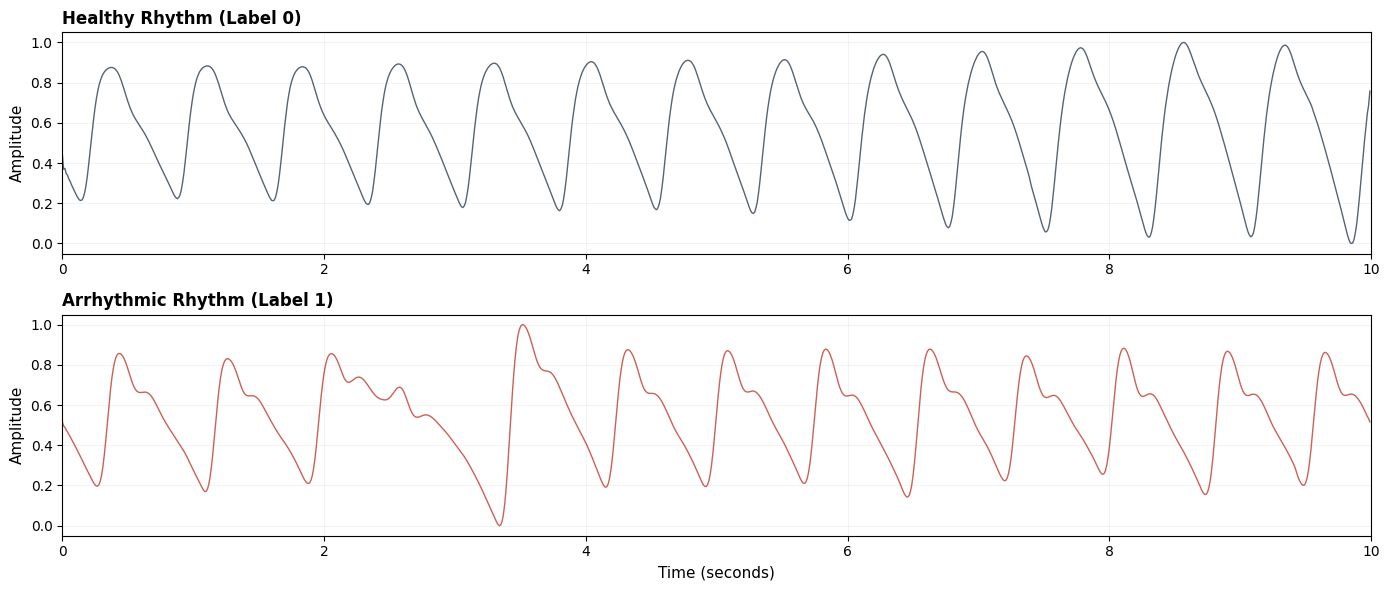

In [ ]:
# ==================== SELECT SAMPLE SIGNALS ====================
idx_healthy = np.where(train_labels == 0)[0][1]  # First healthy sample
idx_arr = np.random.choice(np.where(train_labels == 1)[0])  # Random arrhythmic sample

# Calculate time axis in seconds
sampling_rate = 100  # Hz
time_axis = np.arange(n_samples) / sampling_rate

# ==================== PLOT COMPARISON ====================
fig, axes = plt.subplots(2, 1, figsize=(14, 6), facecolor='white')

# Healthy rhythm
axes[0].plot(time_axis, train_segments[idx_healthy], linewidth=1, color='#2c3e50', alpha=0.8)
axes[0].set_ylabel('Amplitude', fontsize=11)
axes[0].set_title('Healthy Rhythm (Label 0)', fontsize=12, loc='left', fontweight='600')
axes[0].grid(True, alpha=0.2, linewidth=0.5)
axes[0].set_xlim(0, 10)

# Arrhythmic rhythm
axes[1].plot(time_axis, train_segments[idx_arr], linewidth=1, color='#c0392b', alpha=0.8)
axes[1].set_xlabel('Time (seconds)', fontsize=11)
axes[1].set_ylabel('Amplitude', fontsize=11)
axes[1].set_title('Arrhythmic Rhythm (Label 1)', fontsize=12, loc='left', fontweight='600')
axes[1].grid(True, alpha=0.2, linewidth=0.5)
axes[1].set_xlim(0, 10)

plt.tight_layout()
plt.show()

## 🔍 WHAT YOU OBSERVED

From the visualizations above:

### Healthy Rhythms Show:
- Regular, periodic peaks (consistent heartbeats)
- Predictable peak-to-peak intervals
- Smooth, rhythmic waveform patterns
- Minimal baseline variation

### Arrhythmic Signals Display:
- Irregular patterns with inconsistent timing
- Chaotic timing that deviates from normal cardiac function
- Variable peak amplitudes

These visual differences are what your model will learn to detect!

# 🎯 Next Steps: Build Your Model

Your task: preprocess the data, train a classifier, evaluate it, and prepare it for deployment via CAIRE API/dashboard.

**Steps to follow:**
1. **Preprocessing:** normalize, augment if needed.  
2. **Training:** implement with proper validation.  
3. **Evaluation:** report accuracy, precision, recall, F1-score, confusion matrix.  
4. **Export:** save model in deployable format.  

**Things to consider:**
- **Class imbalance:** dataset is 31% healthy / 69% arrhythmic → consider class weights, SMOTE, or focal loss.  
- **Real-time compatibility:** must process 10-second segments efficiently.  
- **Generalization:** model will be tested on rPPG signals (domain shift).  
- **Safety-critical metrics:** decide which evaluation metric matters most.  

**✅ Success Criteria:**  
✓ Accurate on test set  
✓ Real-time ready  
✓ Exportable  
✓ Robust to class imbalance  
✓ Generalizable to new domains (rPPG)

# 🏁 Start Coding
Implement preprocessing, training, and evaluation in the cells below.


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score

# Define the Transformer classifier model with batch_first=True
class SignalTransformerClassifier(nn.Module):
    def __init__(self, seq_len=1000, d_model=64, nhead=4, num_layers=3, num_classes=2):
        super().__init__()
        self.seq_len = seq_len
        self.d_model = d_model

        # Project input scalar at each time step to d_model dimensions
        self.embedding = nn.Linear(1, d_model)

        # Learnable positional encoding
        self.positional_encoding = nn.Parameter(torch.randn(seq_len, d_model))

        # Transformer encoder layers with batch_first=True
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(seq_len * d_model, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        x = x.unsqueeze(-1)  # (batch_size, seq_len, 1)
        x = self.embedding(x)  # (batch_size, seq_len, d_model)
        x = x + self.positional_encoding.unsqueeze(0)  # add positional encoding

        x = self.transformer_encoder(x)  # batch_first=True so no permute needed

        x = x.contiguous()  # (batch_size, seq_len, d_model)
        x = x.view(x.size(0), -1)  # flatten
        logits = self.classifier(x)
        return logits

# Paths and device setup
DATA_PATH = '/content/data'  # Your dataset path
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data from disk
train_segments = np.load(os.path.join(DATA_PATH, 'train', 'train_segments.npy'))  # (35120, 1000)
train_labels = np.load(os.path.join(DATA_PATH, 'train', 'train_labels.npy'))      # (35120,)

# Convert to torch tensors
X = torch.from_numpy(train_segments).float()
y = torch.from_numpy(train_labels).long()

# Split into train and validation sets (e.g., 80/20 split)
num_samples = len(X)
indices = torch.randperm(num_samples)
split = int(num_samples * 0.8)
train_indices = indices[:split]
val_indices = indices[split:]

train_dataset = TensorDataset(X[train_indices], y[train_indices])
val_dataset = TensorDataset(X[val_indices], y[val_indices])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Instantiate model, loss, optimizer
model = SignalTransformerClassifier(seq_len=1000, d_model=64, nhead=4, num_layers=3, num_classes=2)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop (1 epoch example)
num_epochs = 10  # number of epochs you want

for epoch in range(num_epochs):
    model.train()
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    # (Optional) Validation code runs here to monitor progress after each epoch

In [ ]:
DATA_PATH = "./CAIRE_PPG_Arrhythmia_Dataset"   # 🔁 Change to your actual data path
# ----- Config -----
EPOCHS = 10               # stop around epoch 10
BATCH_SIZE = 128
FOLDS = 5
VAL_SPLIT = 0.2           # used internally by fit() if desired (optional)
SEED = 42

# ======================================================
# 🧠 PREPROCESSING
# ======================================================

# Add channel dimension for Conv1D
X_train = train_segments[..., np.newaxis]
X_test = test_segments[..., np.newaxis]

y_train = train_labels
y_test = test_labels

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

# Compute class weights for imbalance handling
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))
print("⚖️ Class Weights:", class_weight_dict)
print()


X_train shape: (35120, 1000, 1), X_test shape: (11707, 1000, 1)
⚖️ Class Weights: {np.int64(0): np.float64(1.6032137313977906), np.int64(1): np.float64(0.7266106674390698)}



In [ ]:
# ======================================================
# 🩺 5-Fold Cross-Validation with Early Stopping (max 10 epochs)
# ======================================================

# ----- Data -----
X = train_segments[..., np.newaxis]
y = train_labels

# ----- Config -----
EPOCHS = 10               # stop around epoch 10
BATCH_SIZE = 128
FOLDS = 5
VAL_SPLIT = 0.2           # used internally by fit() if desired (optional)
SEED = 42

# ----- Model builder -----
def build_ppg_model(input_shape):
    model = Sequential([
        Conv1D(32, kernel_size=7, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(64, kernel_size=5, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Bidirectional(LSTM(64, return_sequences=False)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ----- Cross-Validation -----
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
fold_no = 1

val_accuracies, val_aucs = [], []
best_epochs = []

for train_idx, val_idx in skf.split(X, y):
    print(f"\n🔁 Fold {fold_no}/{FOLDS}")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=2,                # stops early if val_loss doesn’t improve for 2 epochs
        restore_best_weights=True,
        verbose=1
    )

    # build model
    model = build_ppg_model(input_shape=(X.shape[1], 1))

    # train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )

    # validation predictions
    y_val_pred = (model.predict(X_val) > 0.5).astype(int)
    y_val_prob = model.predict(X_val).ravel()

    acc = (y_val_pred.reshape(-1) == y_val).mean()
    auc = roc_auc_score(y_val, y_val_prob)
    val_accuracies.append(acc)
    val_aucs.append(auc)

    # store epoch number of best val_loss
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_epochs.append(best_epoch)
    print(f"Fold {fold_no}: Best epoch = {best_epoch}")

    print(f"Fold {fold_no} → Val Accuracy: {acc:.4f} | Val AUC: {auc:.4f}")
    fold_no += 1

# ----- Aggregated Results -----
print("\n📊 Cross-Validation Summary")
print("------------------------------------------------")
print(f"Mean Validation Accuracy : {np.mean(val_accuracies):.4f} ± {np.std(val_accuracies):.4f}")
print(f"Mean Validation AUC     : {np.mean(val_aucs):.4f} ± {np.std(val_aucs):.4f}")
optimal_epochs = int(np.round(np.mean(best_epochs)))
print(f"\n📊 Mean optimal epoch from 5 folds = {optimal_epochs}")


🔁 Fold 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.7924 - loss: 0.4373 - val_accuracy: 0.6881 - val_loss: 1.2328
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8832 - loss: 0.2845 - val_accuracy: 0.7106 - val_loss: 0.7390
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9175 - loss: 0.2220 - val_accuracy: 0.8981 - val_loss: 0.3369
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9103 - loss: 0.2296 - val_accuracy: 0.6881 - val_loss: 0.9754
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9299 - loss: 0.1979 - val_accuracy: 0.7232 - val_loss: 0.9447
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Fold 1: Best epoch = 3
Fold 1 → Val Accuracy: 0.8981 | Val AUC: 0.9507

🔁 Fold 2/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.7774 - loss: 0.4683 - val_accuracy: 0.6881 - val_loss: 1.4925
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8831 - loss: 0.3053 - val_accuracy: 0.6881 - val_loss: 1.3339
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9018 - loss: 0.2600 - val_accuracy: 0.8937 - val_loss: 0.3418
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.8997 - loss: 0.2548 - val_accuracy: 0.7981 - val_loss: 0.4404
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9044 - loss: 0.2603 - val_accuracy: 0.9198 - val_loss: 0.2247
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8676 - loss: 0.3350 - val_accuracy: 0.9169 - val_loss: 0.2284
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.8900 - loss: 0.2848 - val_accuracy: 0.9137 - val_loss: 0.2712
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.
220/220 ━━━━━

...

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.7808 - loss: 0.4567 - val_accuracy: 0.6881 - val_loss: 1.2972
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.8928 - loss: 0.2777 - val_accuracy: 0.6881 - val_loss: 0.8049
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9123 - loss: 0.2315 - val_accuracy: 0.8882 - val_loss: 0.2905
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.8217 - loss: 0.3732 - val_accuracy: 0.9233 - val_loss: 0.3067
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9246 - loss: 0.2435 - val_accuracy: 0.9254 - val_loss: 0.2240
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9203 - loss: 0.2288 - val_accuracy: 0.7158 - val_loss: 0.5326
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.8538 - loss: 0.3434 - val_accuracy: 0.8993 - val_loss: 0.2495
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.
220/220 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.7897 - loss: 0.4415 - val_accuracy: 0.6882 - val_loss: 1.4152
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.8605 - loss: 0.3399 - val_accuracy: 0.6882 - val_loss: 0.8524
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.8940 - loss: 0.2671 - val_accuracy: 0.7732 - val_loss: 0.4826
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9002 - loss: 0.2624 - val_accuracy: 0.8810 - val_loss: 0.3073
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9040 - loss: 0.2486 - val_accuracy: 0.9140 - val_loss: 0.2188
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9108 - loss: 0.2440 - val_accuracy: 0.9053 - val_loss: 0.2462
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9096 - loss: 0.2441 - val_accuracy: 0.8364 - val_loss: 0.5731
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.
220/220 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.7877 - loss: 0.4471 - val_accuracy: 0.6882 - val_loss: 1.3486
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9023 - loss: 0.2788 - val_accuracy: 0.7442 - val_loss: 0.7290
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8912 - loss: 0.2713 - val_accuracy: 0.8629 - val_loss: 0.2943
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9109 - loss: 0.2365 - val_accuracy: 0.7672 - val_loss: 0.4442
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9245 - loss: 0.1991 - val_accuracy: 0.9416 - val_loss: 0.1515
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9304 - loss: 0.1915 - val_accuracy: 0.6959 - val_loss: 1.0194
Epoch 7/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9365 - loss: 0.1754 - val_accuracy: 0.9455 - val_loss: 0.1534
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.
220/220 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 994, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 994, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 497, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 493, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 493, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 246, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 246, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,313 (333.25 KB)

 Trainable params: 85,121 (332.50 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8088 - loss: 0.4154
Epoch 1: val_loss improved from inf to 1.99863, saving model to final_best_ppg_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.8091 - loss: 0.4150 - val_accuracy: 0.6975 - val_loss: 1.9986
Epoch 2/10
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9031 - loss: 0.2471
Epoch 2: val_loss improved from 1.99863 to 0.84683, saving model to final_best_ppg_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9031 - loss: 0.2472 - val_accuracy: 0.6975 - val_loss: 0.8468
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9076 - loss: 0.2266
Epoch 3: val_loss did not improve from 0.84683
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9077 - loss: 0.2266 - val_accuracy: 0.8216 - val_loss: 0.8813
Epoch 4/10
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9351 - loss: 0.1904
Epoch 4: val_loss improved from 0.84683 to 0.22054, saving model

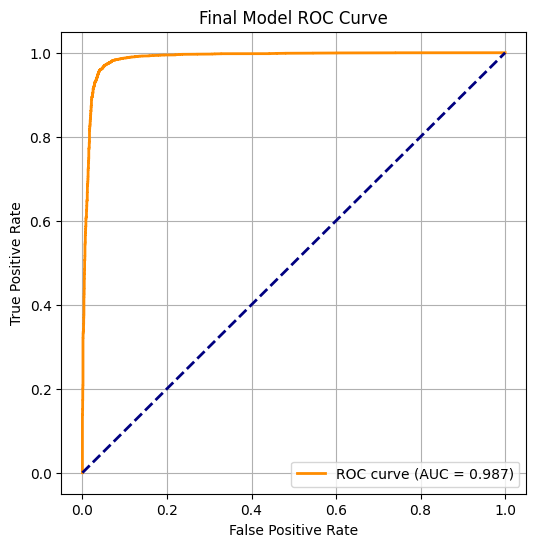

 Final Test ROC-AUC: 0.9873
✅ Final model saved as: final_best_ppg_model.keras


In [ ]:
# ======================================================
#  Final Model Training on Full Training Set
# ======================================================

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Use same input as before
X_train_full = train_segments[..., np.newaxis]
y_train_full = train_labels
X_test_full  = test_segments[..., np.newaxis]
y_test_full  = test_labels

# ======================================================
#  Build Model (same architecture from CV)
# ======================================================
def build_ppg_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(32, kernel_size=7, activation='relu', input_shape=input_shape),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(pool_size=2),

        tf.keras.layers.Conv1D(64, kernel_size=5, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=False)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_ppg_model(input_shape=(X_train_full.shape[1], 1))
model.summary()

# ======================================================
#  Early Stopping & Checkpoint
# ======================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "final_best_ppg_model.keras",   # modern .keras format
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# ======================================================
#  Train Final Model
# ======================================================
EPOCHS = optimal_epochs + 2
BATCH_SIZE = 128

history = model.fit(
    X_train_full, y_train_full,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# ======================================================
#  Evaluate on Held-Out Test Set
# ======================================================
y_pred_prob = model.predict(X_test_full).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n Classification Report:")
print(classification_report(y_test_full, y_pred, digits=4))

cm = confusion_matrix(y_test_full, y_pred)
print("\n Confusion Matrix:\n", cm)

# ======================================================
#  ROC / AUC Visualization
# ======================================================
fpr, tpr, _ = roc_curve(y_test_full, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final Model ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f" Final Test ROC-AUC: {roc_auc:.4f}")

# ======================================================
# 🧩 Save Final Model
# ======================================================
model.save("final_best_ppg_model.keras")
print("✅ Final model saved as: final_best_ppg_model.keras")


In [ ]:
# ======================================================
# MODEL DEFINITION — CNN + BiLSTM
# ======================================================

def build_ppg_model(input_shape):
    model = Sequential([
        Conv1D(32, kernel_size=7, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(64, kernel_size=5, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Bidirectional(LSTM(64, return_sequences=False)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')  # Binary output
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_ppg_model(input_shape=(n_samples, 1))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 994, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 994, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 497, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 493, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 493, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 246, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 246, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,313 (333.25 KB)

 Trainable params: 85,121 (332.50 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# ======================================================
#  TRAINING
# ======================================================

# Stop if val_loss doesn't improve for 4 epochs
early_stop = EarlyStopping(
    monitor='val_loss',       # what to watch (could be 'val_accuracy' instead)
    patience=4,               # how many epochs to wait for improvement
    restore_best_weights=True, # revert to the best model weights
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_ppg_arrhythmia_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7360 - loss: 0.4816
Epoch 1: val_loss improved from inf to 1.21365, saving model to best_ppg_arrhythmia_model.h5


220/220 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.7364 - loss: 0.4812 - val_accuracy: 0.6975 - val_loss: 1.2137
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8948 - loss: 0.2786
Epoch 2: val_loss improved from 1.21365 to 0.75353, saving model to best_ppg_arrhythmia_model.h5


220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.8948 - loss: 0.2786 - val_accuracy: 0.6975 - val_loss: 0.7535
Epoch 3/20
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9058 - loss: 0.2497
Epoch 3: val_loss improved from 0.75353 to 0.34545, saving model to best_ppg_arrhythmia_model.h5


220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9058 - loss: 0.2497 - val_accuracy: 0.8539 - val_loss: 0.3454
Epoch 4/20
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8917 - loss: 0.2810
Epoch 4: val_loss did not improve from 0.34545
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.8916 - loss: 0.2811 - val_accuracy: 0.8804 - val_loss: 0.3559
Epoch 5/20
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9039 - loss: 0.2497
Epoch 5: val_loss improved from 0.34545 to 0.30921, saving model to best_ppg_arrhythmia_model.h5


220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9037 - loss: 0.2502 - val_accuracy: 0.8608 - val_loss: 0.3092
Epoch 6/20
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8889 - loss: 0.2787
Epoch 6: val_loss improved from 0.30921 to 0.17133, saving model to best_ppg_arrhythmia_model.h5


220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.8890 - loss: 0.2785 - val_accuracy: 0.9347 - val_loss: 0.1713
Epoch 7/20
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9396 - loss: 0.1850
Epoch 7: val_loss did not improve from 0.17133
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9396 - loss: 0.1849 - val_accuracy: 0.9328 - val_loss: 0.1808
Epoch 8/20
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9376 - loss: 0.1792
Epoch 8: val_loss did not improve from 0.17133
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9377 - loss: 0.1791 - val_accuracy: 0.9403 - val_loss: 0.2209
Epoch 9/20
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9544 - loss: 0.1563
Epoch 9: val_loss improved from 0.17133 to 0.10310, saving model to best_ppg_arrhythmia_model.h5


220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9544 - loss: 0.1561 - val_accuracy: 0.9678 - val_loss: 0.1031
Epoch 10/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9597 - loss: 0.1269
Epoch 10: val_loss improved from 0.10310 to 0.09496, saving model to best_ppg_arrhythmia_model.h5


220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9597 - loss: 0.1269 - val_accuracy: 0.9658 - val_loss: 0.0950
Epoch 11/20
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9653 - loss: 0.1022
Epoch 11: val_loss did not improve from 0.09496
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9653 - loss: 0.1021 - val_accuracy: 0.9658 - val_loss: 0.1176
Epoch 12/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9450 - loss: 0.1602
Epoch 12: val_loss did not improve from 0.09496
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9450 - loss: 0.1601 - val_accuracy: 0.9247 - val_loss: 0.2657
Epoch 13/20
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9177 - loss: 0.2215
Epoch 13: val_loss did not improve from 0.09496
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9176 - loss: 0.2218 - val_accuracy: 0.8347 - val_loss: 0.4345
Epoch 14/20
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9166 - loss: 0.2131
Epoch 14: val_loss did not impro

366/366 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step

📊 Classification Report:
              precision    recall  f1-score   support

           0     0.9285    0.9775    0.9524      3651
           1     0.9896    0.9659    0.9776      8056

    accuracy                         0.9695     11707
   macro avg     0.9590    0.9717    0.9650     11707
weighted avg     0.9705    0.9695    0.9697     11707


🧮 Confusion Matrix:
 [[3569   82]
 [ 275 7781]]


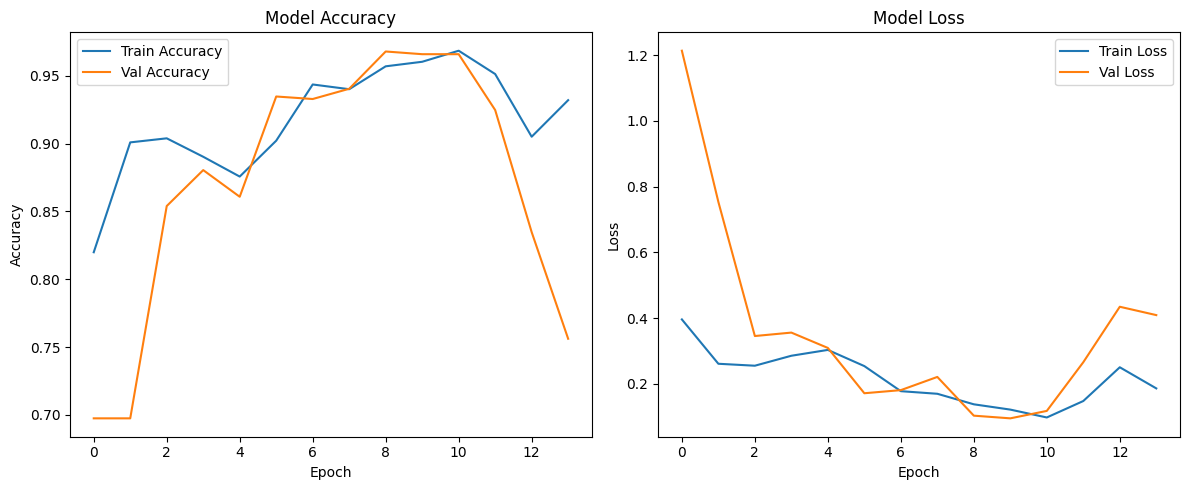

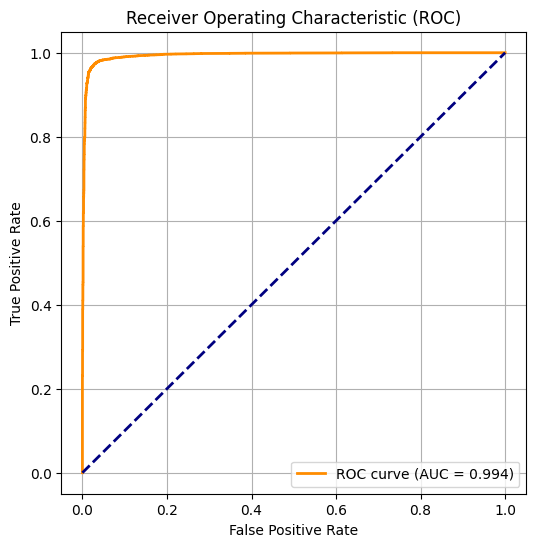

🏁 Final ROC-AUC: 0.9941
✅ Best model saved as: best_ppg_arrhythmia_model.h5


In [ ]:
# ======================================================
# 🧮 EVALUATION
# ======================================================
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("\n🧮 Confusion Matrix:\n", cm)

# ======================================================
# 📈 VISUALIZATION
# ======================================================

# --- Accuracy & Loss curves ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"🏁 Final ROC-AUC: {roc_auc:.4f}")
print("✅ Best model saved as: best_ppg_arrhythmia_model.h5")

## 🔗 NEXT PHASE: FROM PPG ➜ rPPG (CAIRE Cloud Integration)

Now that you’ve trained your model on clean **PPG signals**, it’s time to test how well it generalizes to **real-world driver videos**.

In the next phase, you’ll:

1. **Access the CAIRE Cloud API** to extract **rPPG signals** (remote PPG) from driver videos.  
2. **Preprocess the rPPG data** to match your training setup (e.g., 10-second segments @ 100 Hz).  
3. **Apply your trained model** to these signals and evaluate its ability to detect arrhythmia in natural driving conditions.  
4. **Integrate predictions into your dashboard**, visualizing health alerts in real time.  
5. **Reflect on domain adaptation** — how well does a model trained on contact-based data handle noisy, camera-based signals?
